# 12 — TBM-X Benchmark Validation & Final Design Check

Temel prensip: benchmark'a zorla uydurmak değil, benchmark ile doğrulamak. Ayrıca stall-speed problemini teşhis eden ayrı bir kontrol içerir.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
OUT=Path('outputs/benchmark_validation'); OUT.mkdir(parents=True,exist_ok=True)
benchmark=pd.DataFrame({'aircraft':['TBM 900','TBM 930','TBM 940','TBM 960'],'MTOW_kg':[3354,3354,3354,3700],'wing_area_m2':[18,18,18,18],'cruise_speed_kt':[330,330,330,330]})
tbmx=pd.Series({'aircraft':'TBM-X','MTOW_kg':3400,'wing_area_m2':18,'cruise_speed_kt':300})
comparison=pd.concat([benchmark,pd.DataFrame([tbmx])],ignore_index=True); comparison

,aircraft,MTOW_kg,wing_area_m2,cruise_speed_kt
0,TBM 900,3354,18,330
1,TBM 930,3354,18,330
2,TBM 940,3354,18,330
3,TBM 960,3700,18,330
4,TBM-X,3400,18,300


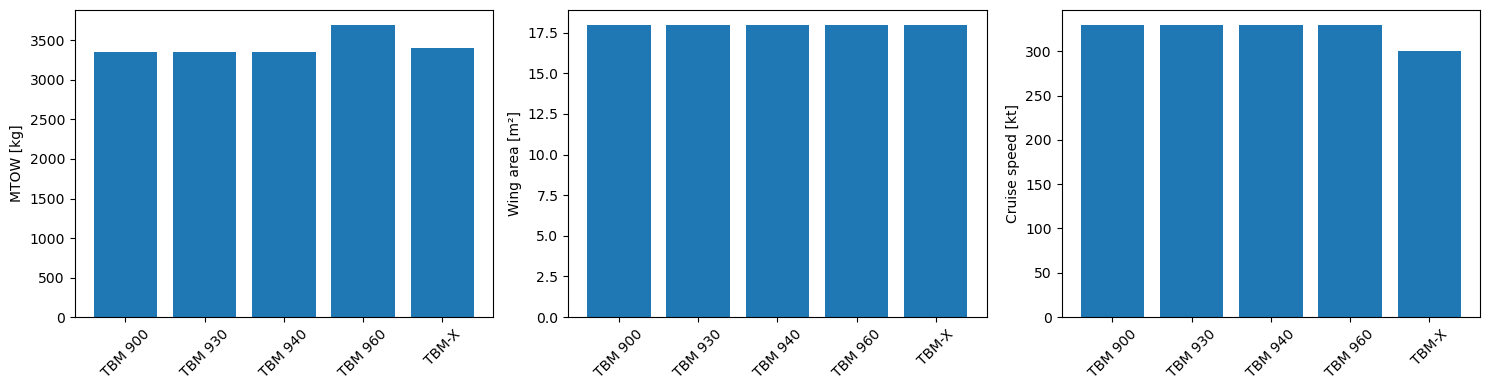

In [2]:
fig,ax=plt.subplots(1,3,figsize=(15,4));
for a,c,t in zip(ax,['MTOW_kg','wing_area_m2','cruise_speed_kt'],['MTOW [kg]','Wing area [m²]','Cruise speed [kt]']): ax[list(['MTOW_kg','wing_area_m2','cruise_speed_kt']).index(c)].bar(comparison.aircraft,comparison[c]); a.set_ylabel(t); a.tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.show()

In [3]:
# Stall-speed diagnostic: use sea-level density, not cruise-altitude density.
RHO_SL=1.225; G=9.80665; KTMS=.514444; CL_MAX=1.8
W=tbmx.MTOW_kg*G; Vs_ms=np.sqrt(2*W/(RHO_SL*tbmx.wing_area_m2*CL_MAX)); Vs_kt=Vs_ms/KTMS
print(f'Preliminary sea-level stall speed = {Vs_kt:.1f} kt')
path=Path('data/generated/feasible_designs.csv')
if path.exists():
    df=pd.read_csv(path)
    if 'stall_speed_kt' in df:
        print(df.stall_speed_kt.describe())
        for lim in [65,75,85,95,105]: print(f'<= {lim} kt:',int((df.stall_speed_kt<=lim).sum()))
else: print('Generated dataset not found; run dataset generation first.')

Preliminary sea-level stall speed = 79.7 kt
Generated dataset not found; run dataset generation first.


In [ ]:
median=benchmark[['MTOW_kg','wing_area_m2','cruise_speed_kt']].median(); dev=(tbmx[['MTOW_kg','wing_area_m2','cruise_speed_kt']]-median)/median*100
deviation=pd.DataFrame({'parameter':dev.index,'benchmark_median':median.values,'TBM_X':tbmx[dev.index].values,'deviation_percent':dev.values}); deviation.to_csv(OUT/'benchmark_relative_deviation.csv',index=False)
checks=pd.DataFrame({'check':['MTOW','Wing area','Cruise speed','Stall calculation'],'status':['PASS' if abs(dev.MTOW_kg)<15 else 'REVIEW','PASS' if abs(dev.wing_area_m2)<15 else 'REVIEW','PASS' if abs(dev.cruise_speed_kt)<20 else 'REVIEW','PASS' if Vs_kt>0 else 'REVIEW']}); checks.to_csv(OUT/'final_conceptual_checks.csv',index=False); comparison.to_csv(OUT/'tbmx_benchmark_comparison.csv',index=False); checks